In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Data Read

In [65]:
df = pd.read_csv("iris.csv")

## Data columns

In [66]:
df["variety"].unique()
df["variety"].nunique()

3

## Columns Rename

In [67]:
df["variety"] = df["variety"].apply(lambda x: 'Irıs-Setosa' if x == 'Setosa' else x)
df["variety"] = df["variety"].apply(lambda x: 'Irıs-Virginica' if x == 'Virginica' else x)
df["variety"] = df["variety"].apply(lambda x: 'Irıs-Versicolor' if x == 'Versicolor' else x)

## Columns Replace

In [68]:
df = df.rename(columns={"variety": "species"})
df.columns = df.columns.str.replace(".", "_")


In [90]:
df.head()
df.shape

(150, 5)

## About Data

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## Quarters

In [76]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


## Boxplot diagram of sepal species

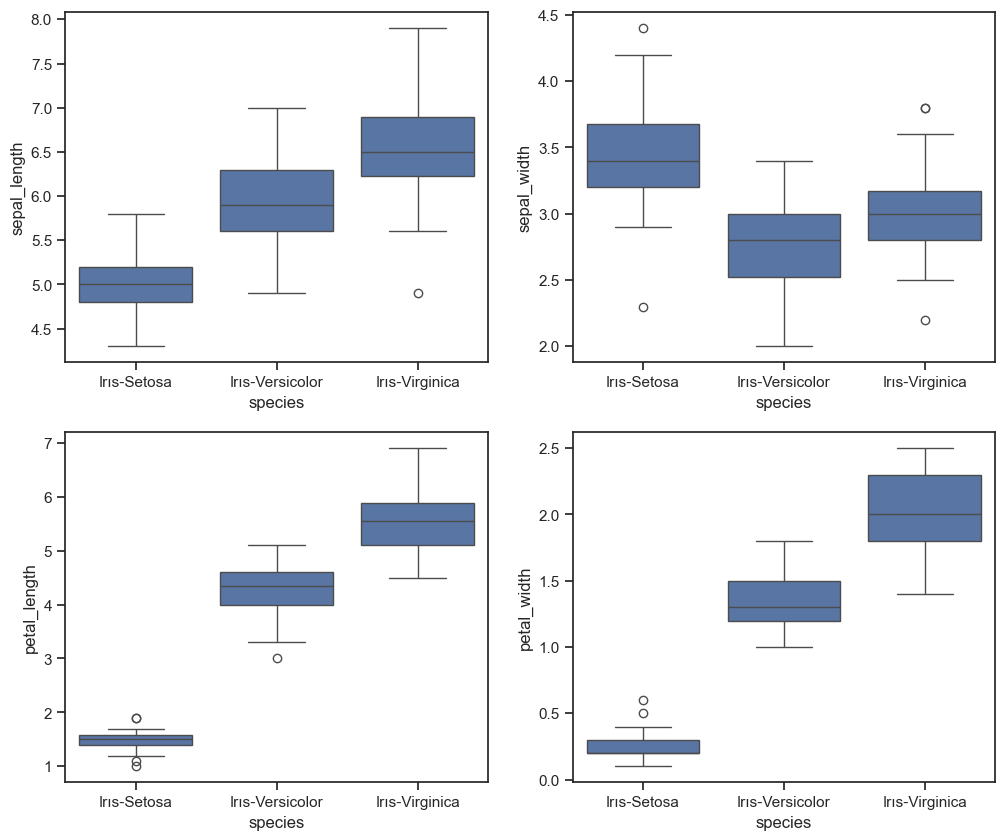

In [79]:
sns.set(style='ticks')
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
sns.boxplot(x= "species", y="sepal_length", data=df)
plt.subplot(2,2,2)
sns.boxplot(x = "species", y="sepal_width", data = df)
plt.subplot(2,2,3)
sns.boxplot(x = "species", y="petal_length", data=df)
plt.subplot(2,2,4)
sns.boxplot(x = "species", y="petal_width", data= df)
plt.show()

In [80]:
df.groupby("species").agg(["mean", "median"])

sepal_length        sepal_width        petal_length         \
                        mean median        mean median         mean median   
species                                                                      
Irıs-Setosa            5.006    5.0       3.428    3.4        1.462   1.50   
Irıs-Versicolor        5.936    5.9       2.770    2.8        4.260   4.35   
Irıs-Virginica         6.588    6.5       2.974    3.0        5.552   5.55   

                petal_width         
                       mean median  
species                             
Irıs-Setosa           0.246    0.2  
Irıs-Versicolor       1.326    1.3  
Irıs-Virginica        2.026    2.0

In [81]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

## Data Correlation and HeatMap Chart

In [84]:
df.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


[]

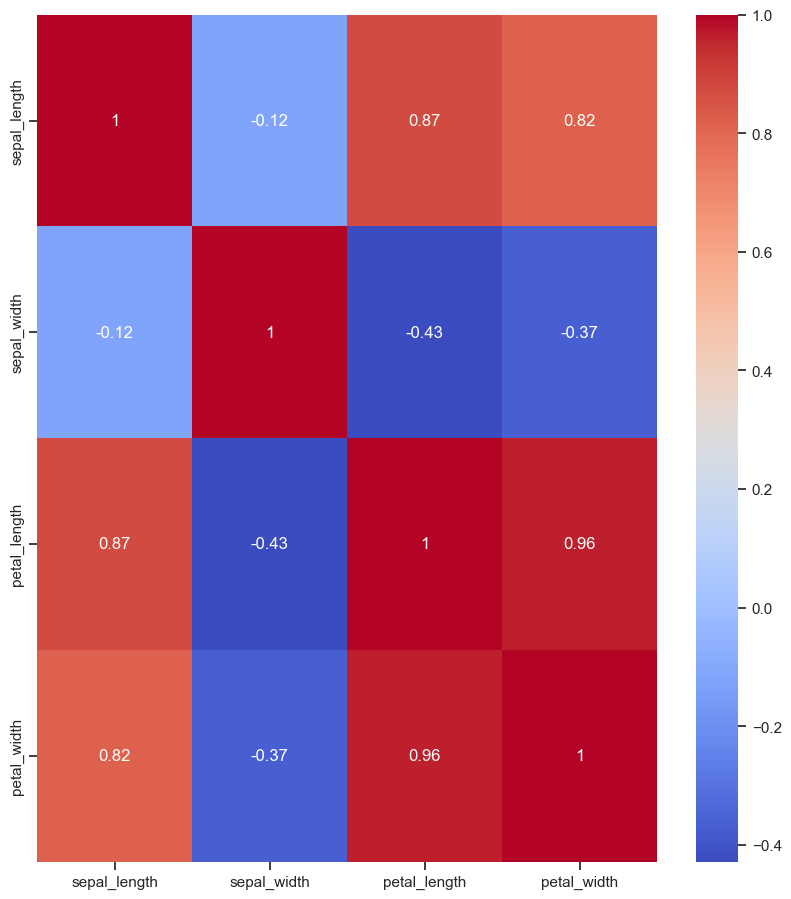

In [87]:
plt.figure(figsize=(10,11))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True)
plt.plot()

## All Data Sepal and Petal charts

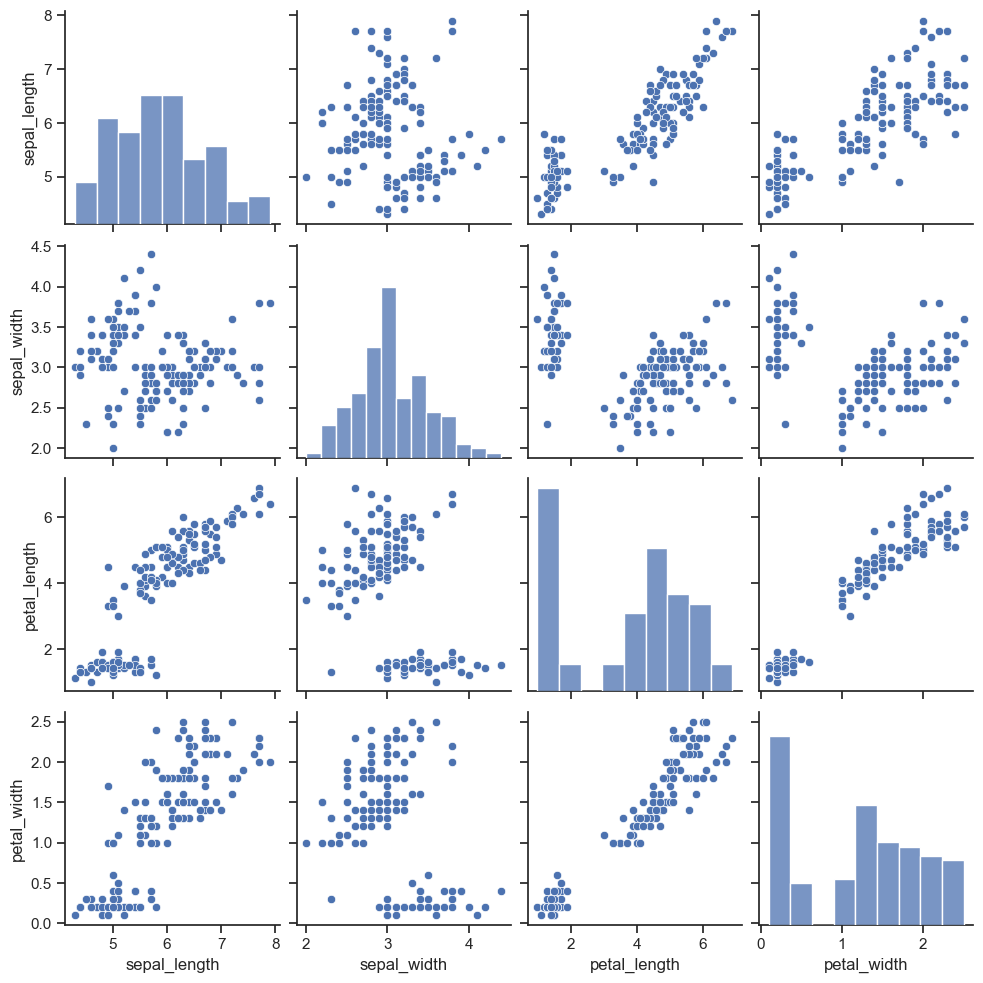

In [89]:
sns.pairplot(df)

## Jointplot 

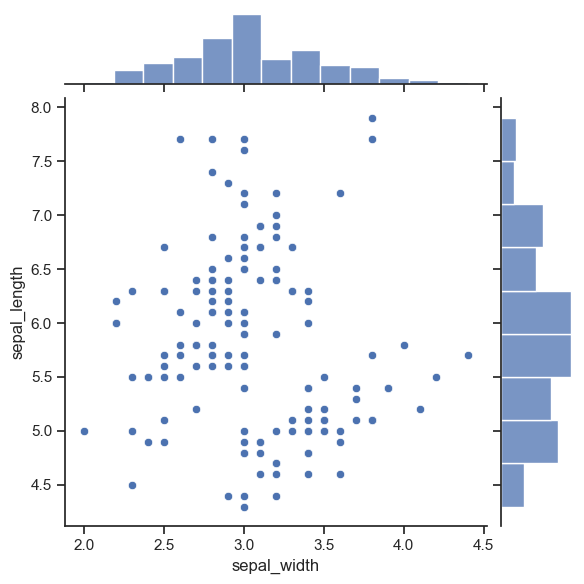

In [102]:
sns.set(style="ticks")
sns.jointplot(x = "sepal_width", y = "sepal_length", data=df, color="b")

## Pairplot ,3rd dimension

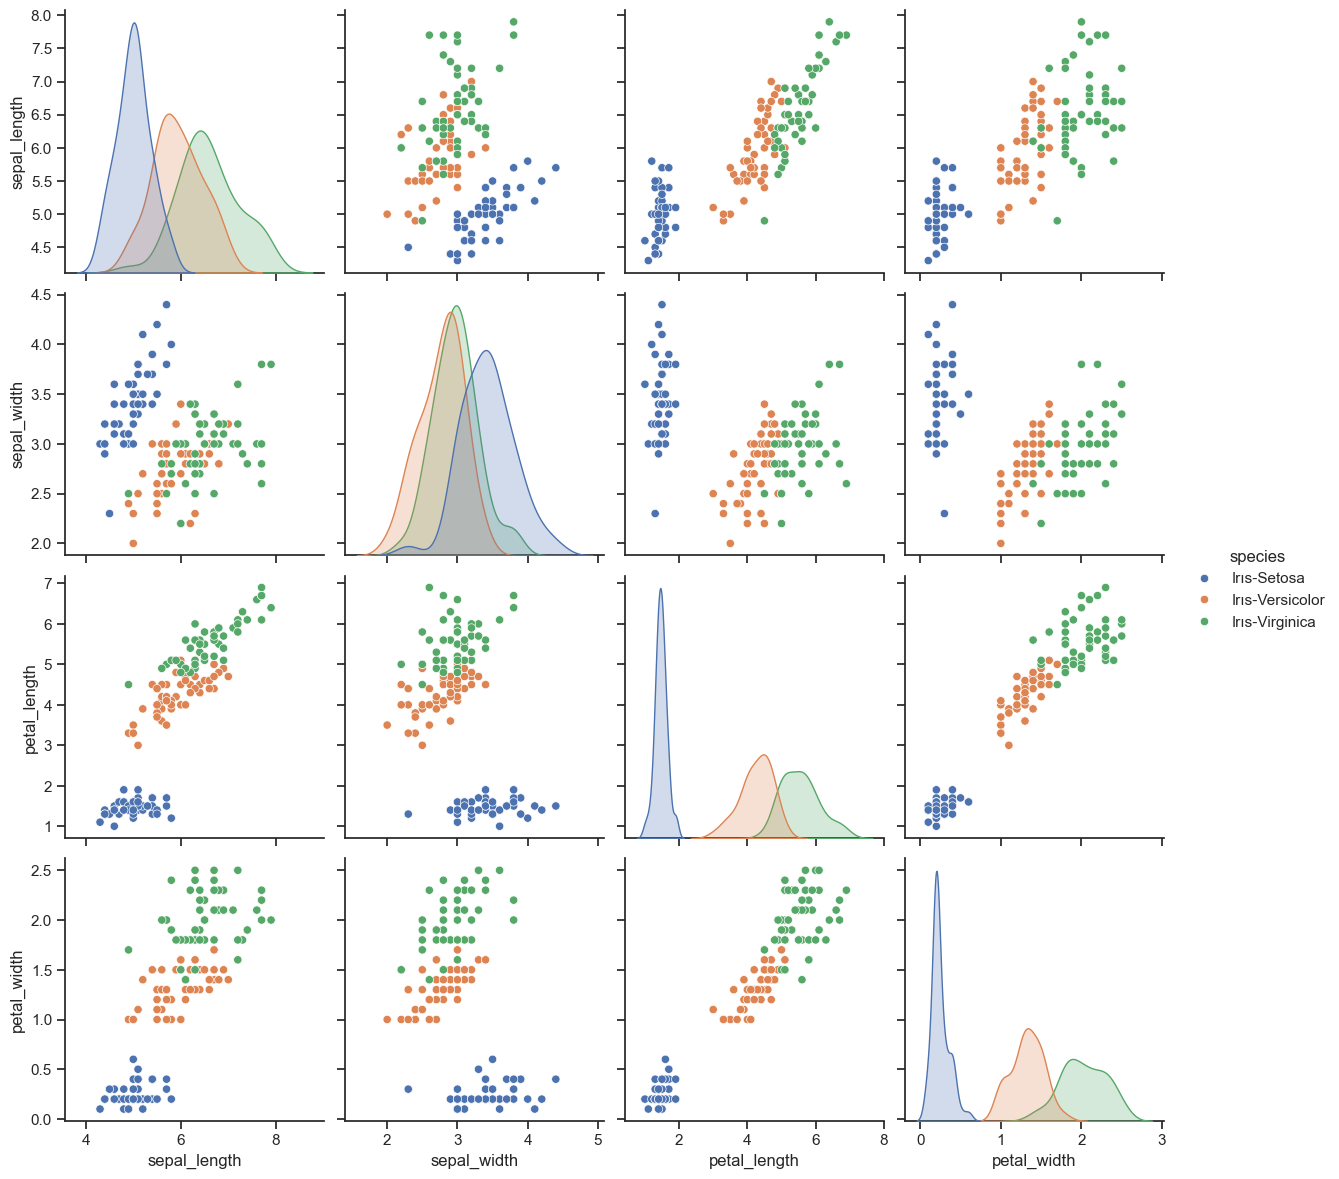

In [106]:
sns.pairplot(df, hue="species", height=3)

## ScatterPlot 

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

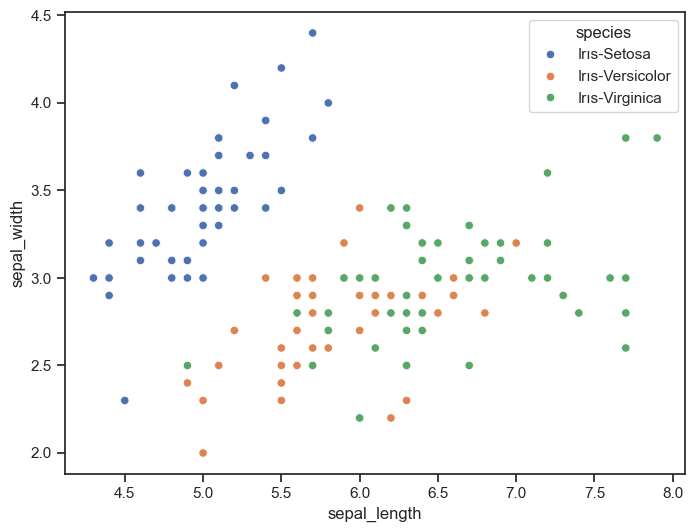

In [108]:
sns.scatterplot(x = "sepal_length", y= "sepal_width", hue = "species", data= df)

## Violinplot 

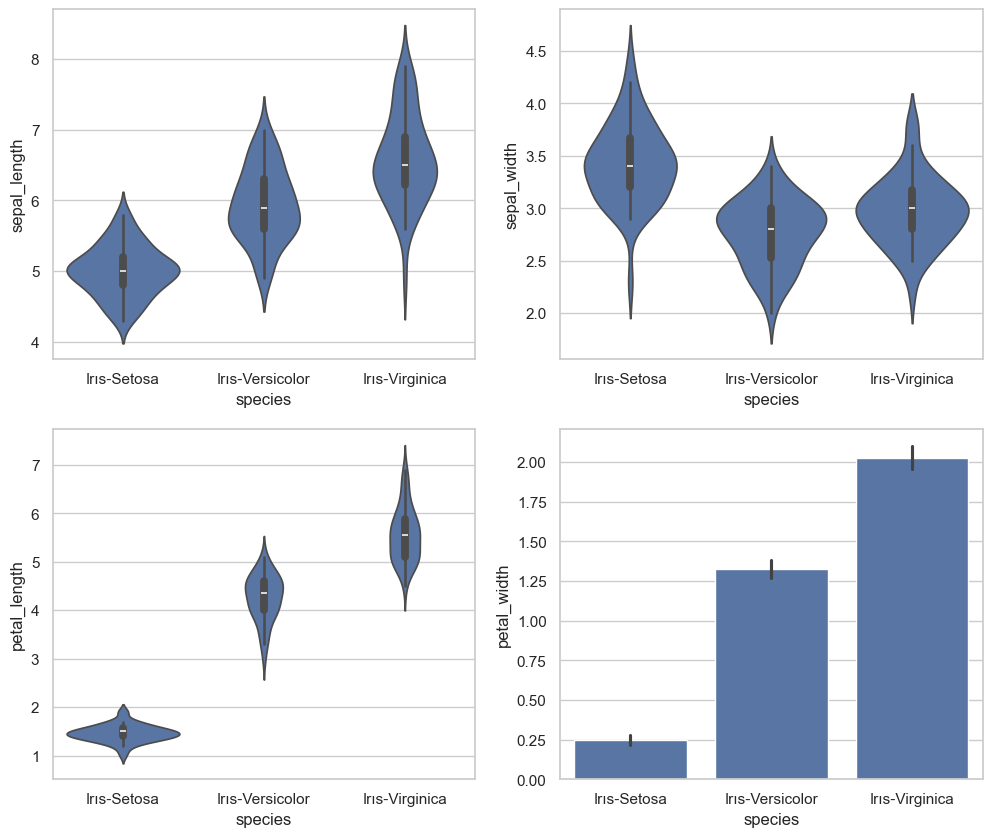

In [114]:
sns.set(style="whitegrid")
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
sns.violinplot( x="species", y="sepal_length", data=df)
plt.subplot(2,2,2)
sns.violinplot(x="species", y= "sepal_width", data=df)
plt.subplot(2,2,3)
sns.violinplot(x="species", y="petal_length",data=df)
plt.subplot(2,2,4)
sns.barplot(x="species", y="petal_width",data=df)
plt.show()



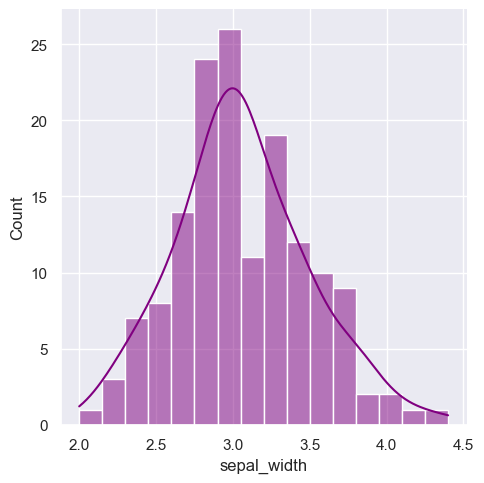

In [129]:
sns.displot(df["sepal_width"],bins=16, color="purple", kde =True)


<Axes: xlabel='species', ylabel='count'>

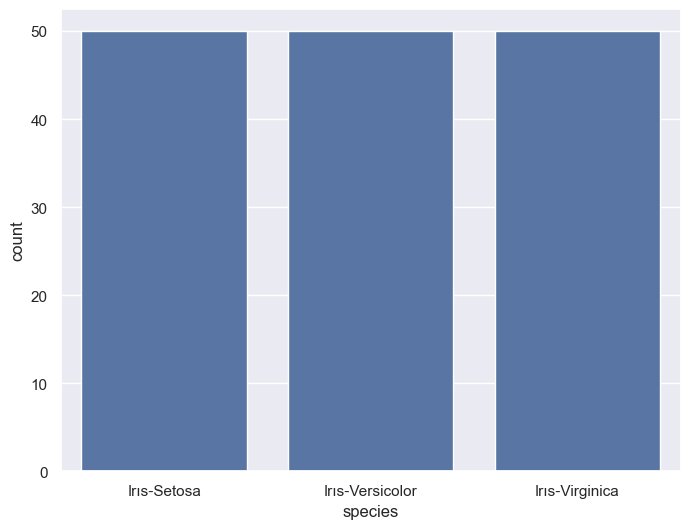

In [128]:
sns.countplot(x="species", data= df)

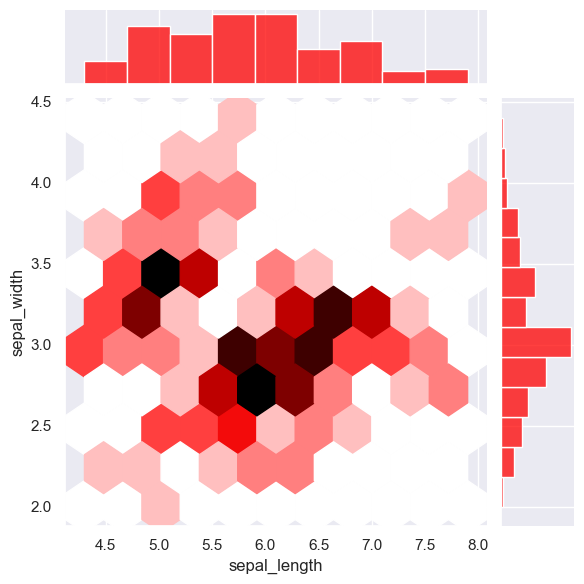

In [130]:
sns.jointplot(x="sepal_length",y="sepal_width",data=df,kind="hex",color="red")

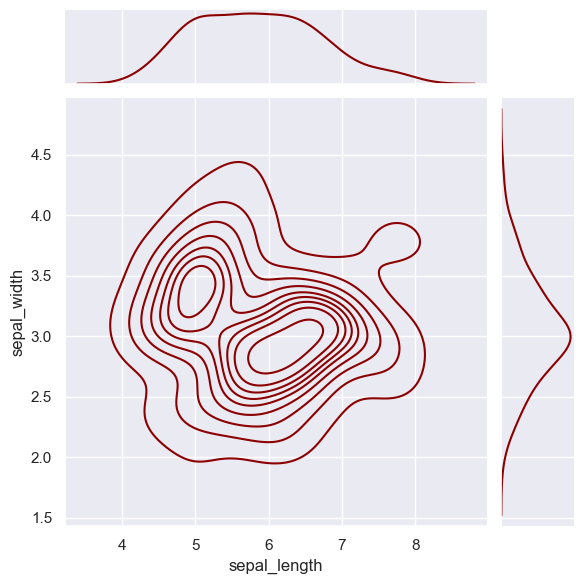

In [134]:
sns.jointplot(x = df["sepal_length"], y=df["sepal_width"], kind="kde",color="darkred")

<Axes: xlabel='sepal_length', ylabel='petal_width'>

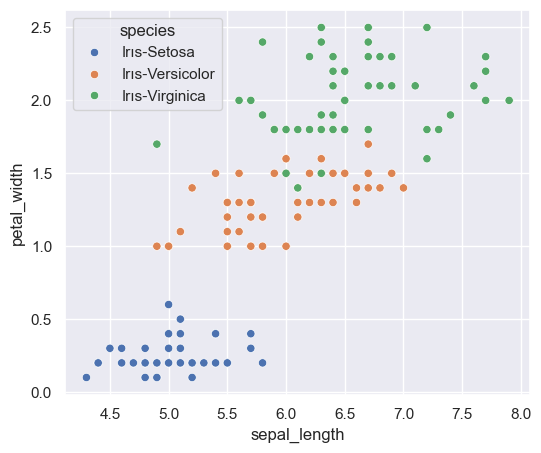

In [145]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="sepal_length", y="petal_width", hue="species", data=df)

## implot-regression

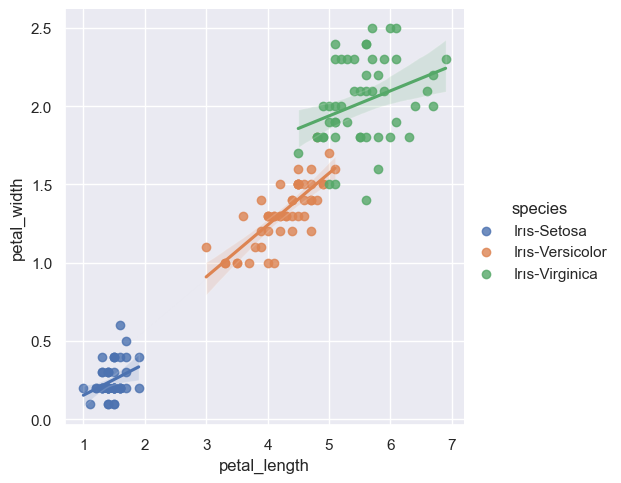

In [ ]:
df.corr(numeric_only=True)["petal_length"]["petal_width"]
sns.lmplot(x="petal_length", y= "petal_width", data= df, hue="species")

## New Columns = TOTAL LENGTH

In [158]:
df["total_length"] = df["sepal_length"] + df["petal_length"]
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,total_length
0,5.1,3.5,1.4,0.2,Irıs-Setosa,6.5
1,4.9,3.0,1.4,0.2,Irıs-Setosa,6.3
2,4.7,3.2,1.3,0.2,Irıs-Setosa,6.0
3,4.6,3.1,1.5,0.2,Irıs-Setosa,6.1
4,5.0,3.6,1.4,0.2,Irıs-Setosa,6.4


In [174]:
## df.total_length.mean()
new_columns_mean = df["total_length"].mean()
new_columns_std = df.total_length.std()
df.describe()
df["species"].unique()


array(['Irıs-Setosa', 'Irıs-Versicolor', 'Irıs-Virginica'], dtype=object)

In [165]:
df.sepal_length.max()

7.9

## grouping process

In [192]:
df[(df["sepal_length"]> 5.5) & (df["species"] == "Irıs-Setosa")]


,sepal_length,sepal_width,petal_length,petal_width,species,total_length
14,5.8,4.0,1.2,0.2,Irıs-Setosa,7.0
15,5.7,4.4,1.5,0.4,Irıs-Setosa,7.2
18,5.7,3.8,1.7,0.3,Irıs-Setosa,7.4


In [ ]:
kosul = df[(df["petal_length"]< 5) & (df["species"]== "Irıs-Virginica")][["sepal_length","sepal_width"]]
kosul
df.iloc[:,0:2][(df["species"]=="Irıs-Virginica") & (df["petal_length"]< 5)]

,sepal_length,sepal_width
106,4.9,2.5
121,5.6,2.8
123,6.3,2.7
126,6.2,2.8
127,6.1,3.0
138,6.0,3.0


In [210]:
df.groupby("species").mean()

,sepal_length,sepal_width,petal_length,petal_width,total_length
species,,,,,
Irıs-Setosa,5.006,3.428,1.462,0.246,6.468
Irıs-Versicolor,5.936,2.770,4.260,1.326,10.196
Irıs-Virginica,6.588,2.974,5.552,2.026,12.140


In [214]:
df.groupby("species")["petal_length"].std()

species
Irıs-Setosa        0.173664
Irıs-Versicolor    0.469911
Irıs-Virginica     0.551895
Name: petal_length, dtype: float64